# Random Forest y Extra Trees — Terrenos

Experimentos de bagging sobre `data/gold/final_land_scraping.csv`. Se prueban cuatro variantes:

| Modelo | Descripción |
|---|---|
| **RF base** | Random Forest con hiperparámetros por defecto |
| **ET base** | Extra Trees con hiperparámetros por defecto |
| **RF Optuna** | Random Forest optimizado con Optuna (5-fold CV, 40 trials) |
| **ET Optuna** | Extra Trees optimizado con Optuna (5-fold CV, 40 trials) |

**Punto de atención:** Extra Trees es conocido por presentar overfitting severo en datasets pequeños con pocas features (R²_train ≈ 1, R²_test << R²_train). Con n=812 y 7 features, se espera ese comportamiento. La optimización con Optuna intentará corregirlo vía `min_samples_leaf` y `max_features`.

**Target:** `log_precio`. Métricas finales también en €.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga y preparación

In [ ]:
df = pd.read_csv('../../data/gold/final_land_scraping.csv')

df.columns = (
    df.columns
    .str.replace(' ', '_', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

TARGET   = 'log_precio'
EXCLUDE  = ['precio_eur', TARGET]
FEATURES = [c for c in df.columns if c not in EXCLUDE]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Shape dataset: {df.shape}')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features ({len(FEATURES)}): {FEATURES}')

Shape dataset: (812, 9)
Train: (649, 7) | Test: (163, 7)
Features (7): ['superficie_m2', 'vendido_con_descuento', 'es_urbano_o_urbanizable', 'municipio_encoded', 'tipo_suelo_No_urbanizable', 'tipo_suelo_Urbanizable', 'tipo_suelo_Urbano_solar']


## 2. Función de métricas

In [ ]:
def get_metrics(model, X_tr, X_te, y_tr, y_te, name=''):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    m = {
        'RMSE_train': np.sqrt(mean_squared_error(y_tr, y_pred_tr)),
        'RMSE_test':  np.sqrt(mean_squared_error(y_te, y_pred_te)),
        'R2_train':   r2_score(y_tr, y_pred_tr),
        'R2_test':    r2_score(y_te, y_pred_te),
        'MAE_test':   mean_absolute_error(y_te, y_pred_te),
    }
    if name:
        gap = m['R2_train'] - m['R2_test']
        print(f'--- {name} ---')
        for k, v in m.items():
            print(f'  {k}: {v:.4f}')
        print(f'  Overfitting gap (R2_train - R2_test): {gap:.4f}')
    return m

## 3. Baselines

Punto de partida sin ajuste de hiperparámetros para medir el grado de overfitting inicial.

In [ ]:
rf_base = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train, y_train)
metrics_rf_base = get_metrics(rf_base, X_train, X_test, y_train, y_test, name='Random Forest base')

--- Random Forest base ---
  RMSE_train: 0.2146
  RMSE_test: 0.5485
  R2_train: 0.9312
  R2_test: 0.4666
  MAE_test: 0.4114
  Overfitting gap (R2_train - R2_test): 0.4646


In [ ]:
et_base = ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
et_base.fit(X_train, y_train)
metrics_et_base = get_metrics(et_base, X_train, X_test, y_train, y_test, name='Extra Trees base')

--- Extra Trees base ---
  RMSE_train: 0.0471
  RMSE_test: 0.5479
  R2_train: 0.9967
  R2_test: 0.4678
  MAE_test: 0.3943
  Overfitting gap (R2_train - R2_test): 0.5289


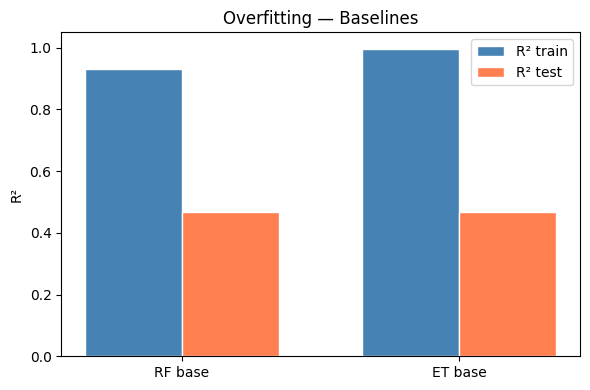

In [ ]:
# Visualización comparativa del overfitting en baseline
labels  = ['RF base', 'ET base']
r2_train = [metrics_rf_base['R2_train'], metrics_et_base['R2_train']]
r2_test  = [metrics_rf_base['R2_test'],  metrics_et_base['R2_test']]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w/2, r2_train, w, label='R² train', color='steelblue',  edgecolor='white')
ax.bar(x + w/2, r2_test,  w, label='R² test',  color='coral',      edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('R²')
ax.set_ylim(0, 1.05)
ax.set_title('Overfitting — Baselines')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Random Forest optimizado con Optuna

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective_rf(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 600),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
    }
    model = RandomForestRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    return -scores.mean()

study_rf = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_rf.optimize(objective_rf, n_trials=40, show_progress_bar=True)

print(f'\nMejor RMSE CV (RF): {study_rf.best_value:.4f}')
print('Mejores hiperparámetros RF:')
for k, v in study_rf.best_params.items():
    print(f'  {k}: {v}')

Best trial: 32. Best value: 0.577463:  82%|████████▎ | 33/40 [00:59<00:23,  3.32s/it]/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sitomachucas/Documents/BezanillaSL/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the sc


Mejor RMSE CV (RF): 0.5775
Mejores hiperparámetros RF:
  n_estimators: 385
  max_depth: 15
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.5


In [ ]:
best_params_rf = study_rf.best_params.copy()
best_params_rf.update({'random_state': RANDOM_STATE, 'n_jobs': -1})

rf_opt = RandomForestRegressor(**best_params_rf)
rf_opt.fit(X_train, y_train)
metrics_rf_opt = get_metrics(rf_opt, X_train, X_test, y_train, y_test, name='Random Forest Optuna')

--- Random Forest Optuna ---
  RMSE_train: 0.4089
  RMSE_test: 0.5348
  R2_train: 0.7500
  R2_test: 0.4929
  MAE_test: 0.4248
  Overfitting gap (R2_train - R2_test): 0.2570


## 5. Extra Trees optimizado con Optuna

In [ ]:
def objective_et(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
    }
    model = ExtraTreesRegressor(**params)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    return -scores.mean()

study_et = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_et.optimize(objective_et, n_trials=40, show_progress_bar=True)

print(f'\nMejor RMSE CV (ET): {study_et.best_value:.4f}')
print('Mejores hiperparámetros ET:')
for k, v in study_et.best_params.items():
    print(f'  {k}: {v}')

Best trial: 31. Best value: 0.589082: 100%|██████████| 40/40 [00:40<00:00,  1.01s/it]


Mejor RMSE CV (ET): 0.5891
Mejores hiperparámetros ET:
  n_estimators: 559
  max_depth: 13
  min_samples_split: 16
  min_samples_leaf: 1
  max_features: 0.5


In [ ]:
best_params_et = study_et.best_params.copy()
best_params_et.update({'random_state': RANDOM_STATE, 'n_jobs': -1})

et_opt = ExtraTreesRegressor(**best_params_et)
et_opt.fit(X_train, y_train)
metrics_et_opt = get_metrics(et_opt, X_train, X_test, y_train, y_test, name='Extra Trees Optuna')

--- Extra Trees Optuna ---
  RMSE_train: 0.5057
  RMSE_test: 0.5269
  R2_train: 0.6177
  R2_test: 0.5079
  MAE_test: 0.4167
  Overfitting gap (R2_train - R2_test): 0.1098


## 6. Curvas de convergencia Optuna

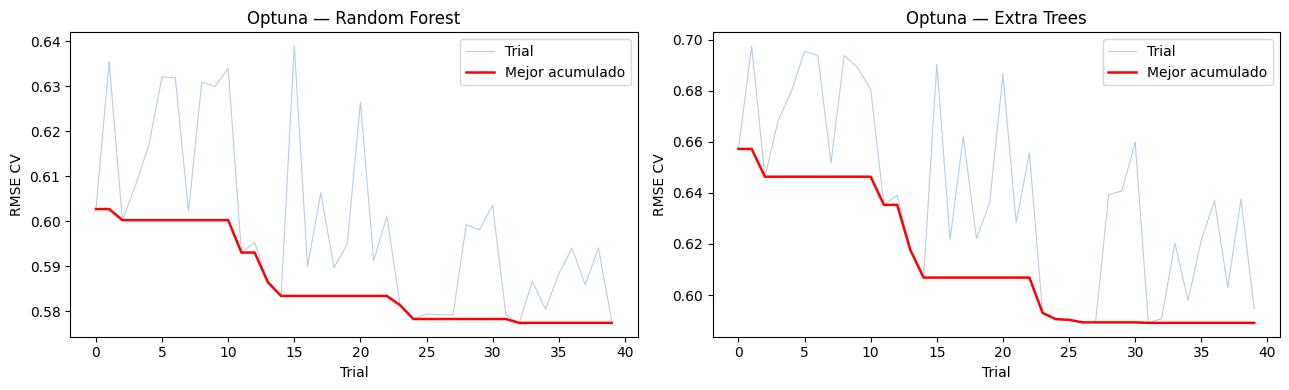

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, study, title in zip(axes, [study_rf, study_et], ['Random Forest', 'Extra Trees']):
    vals = [t.value for t in study.trials]
    ax.plot(vals, color='steelblue', alpha=0.4, linewidth=0.8, label='Trial')
    ax.plot(
        np.minimum.accumulate(vals),
        color='red', linewidth=1.8, label='Mejor acumulado'
    )
    ax.set_xlabel('Trial')
    ax.set_ylabel('RMSE CV')
    ax.set_title(f'Optuna — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Comparativa global de los cuatro modelos

In [ ]:
summary = pd.DataFrame({
    'RF_base':    metrics_rf_base,
    'ET_base':    metrics_et_base,
    'RF_Optuna':  metrics_rf_opt,
    'ET_Optuna':  metrics_et_opt,
}).T.round(4)

summary['Overfitting_gap'] = (summary['R2_train'] - summary['R2_test']).round(4)

print('Comparativa de los cuatro modelos:')
display(summary)

mejor = summary['R2_test'].idxmax()
print(f'\nMejor modelo en test: {mejor} (R²={summary.loc[mejor, "R2_test"]:.4f})')

Comparativa de los cuatro modelos:


,RMSE_train,RMSE_test,R2_train,R2_test,MAE_test,Overfitting_gap
RF_base,0.2146,0.5485,0.9312,0.4666,0.4114,0.4646
ET_base,0.0471,0.5479,0.9967,0.4678,0.3943,0.5289
RF_Optuna,0.4089,0.5348,0.7500,0.4929,0.4248,0.2571
ET_Optuna,0.5057,0.5269,0.6177,0.5079,0.4167,0.1098



Mejor modelo en test: ET_Optuna (R²=0.5079)


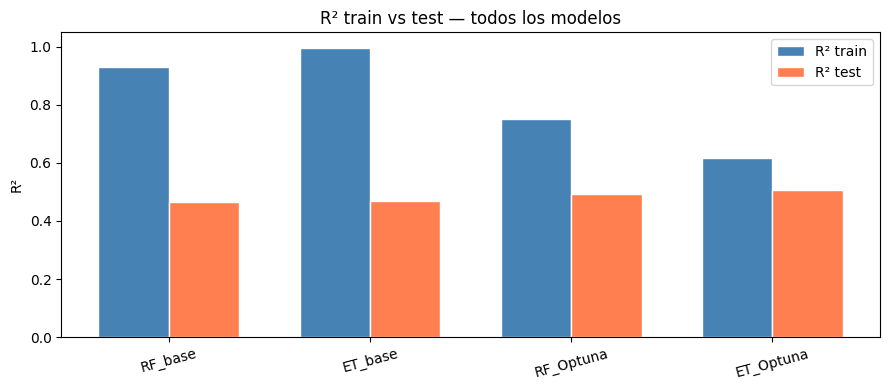

In [ ]:
# Gráfica de overfitting corregido por Optuna
modelos = ['RF_base', 'ET_base', 'RF_Optuna', 'ET_Optuna']
r2_train_vals = [metrics_rf_base['R2_train'], metrics_et_base['R2_train'],
                 metrics_rf_opt['R2_train'],   metrics_et_opt['R2_train']]
r2_test_vals  = [metrics_rf_base['R2_test'],  metrics_et_base['R2_test'],
                 metrics_rf_opt['R2_test'],    metrics_et_opt['R2_test']]

x = np.arange(len(modelos))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, r2_train_vals, w, label='R² train', color='steelblue', edgecolor='white')
ax.bar(x + w/2, r2_test_vals,  w, label='R² test',  color='coral',     edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=15)
ax.set_ylabel('R²')
ax.set_ylim(0, 1.05)
ax.set_title('R² train vs test — todos los modelos')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Importancia de features — mejor modelo

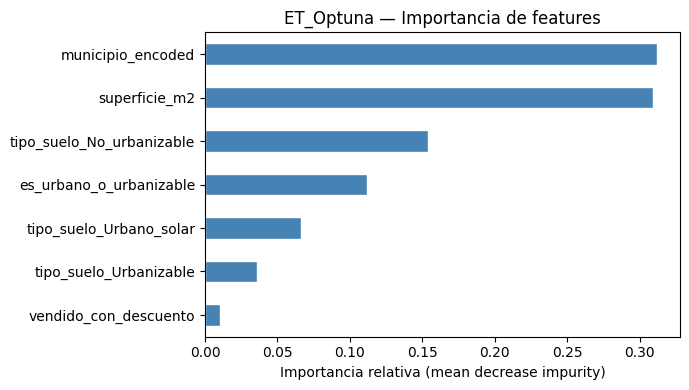

Importancia de features (mayor a menor):
municipio_encoded            0.3123
superficie_m2                0.3092
tipo_suelo_No_urbanizable    0.1539
es_urbano_o_urbanizable      0.1118
tipo_suelo_Urbano_solar      0.0664
tipo_suelo_Urbanizable       0.0361
vendido_con_descuento        0.0103


In [ ]:
mejor_modelo_obj = {
    'RF_base':   rf_base,
    'ET_base':   et_base,
    'RF_Optuna': rf_opt,
    'ET_Optuna': et_opt,
}[mejor]

importance = pd.Series(
    mejor_modelo_obj.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'{mejor} — Importancia de features')
ax.set_xlabel('Importancia relativa (mean decrease impurity)')
plt.tight_layout()
plt.show()

print('Importancia de features (mayor a menor):')
print(importance.sort_values(ascending=False).round(4).to_string())

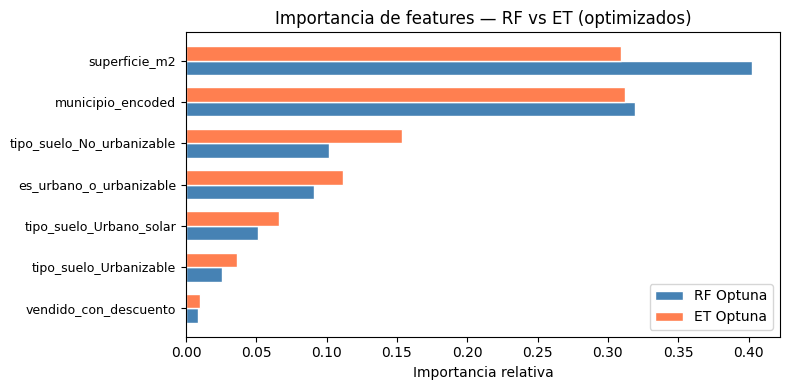

In [ ]:
# Comparativa de importancia RF vs ET (optimizados)
imp_rf = pd.Series(rf_opt.feature_importances_, index=FEATURES, name='RF_Optuna')
imp_et = pd.Series(et_opt.feature_importances_, index=FEATURES, name='ET_Optuna')
imp_df = pd.concat([imp_rf, imp_et], axis=1).sort_values('RF_Optuna')

x = np.arange(len(imp_df))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(x - w/2, imp_df['RF_Optuna'], w, label='RF Optuna', color='steelblue', edgecolor='white')
ax.barh(x + w/2, imp_df['ET_Optuna'], w, label='ET Optuna', color='coral',     edgecolor='white')
ax.set_yticks(x)
ax.set_yticklabels(imp_df.index, fontsize=9)
ax.set_title('Importancia de features — RF vs ET (optimizados)')
ax.set_xlabel('Importancia relativa')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Diagnóstico de residuos — mejor modelo

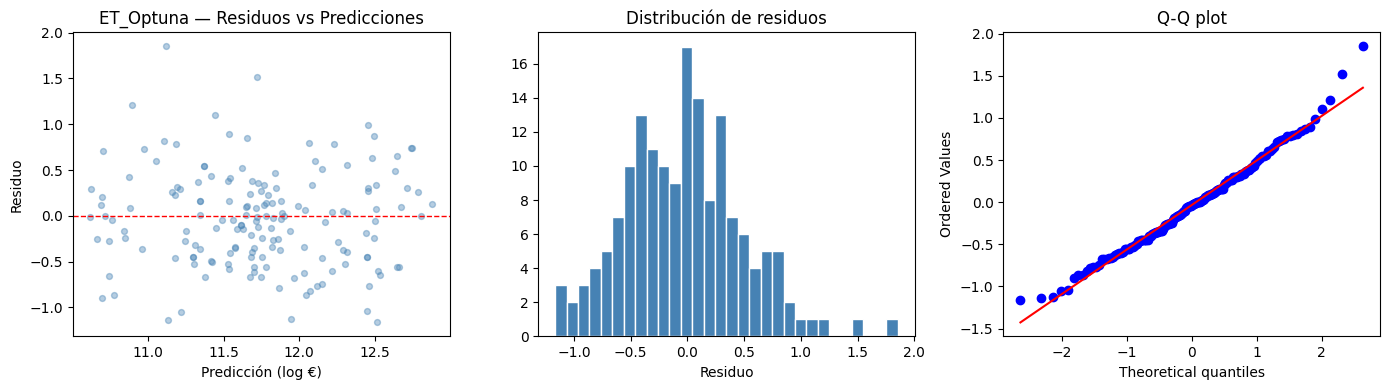

Skewness residuos: 0.4230
Kurtosis residuos: 0.4960


In [ ]:
y_pred_test = mejor_modelo_obj.predict(X_test)
residuals   = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_pred_test, residuals, alpha=0.4, color='steelblue', s=18)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicción (log €)')
axes[0].set_ylabel('Residuo')
axes[0].set_title(f'{mejor} — Residuos vs Predicciones')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo')

stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q plot')

plt.tight_layout()
plt.show()

print(f'Skewness residuos: {pd.Series(residuals).skew():.4f}')
print(f'Kurtosis residuos: {pd.Series(residuals).kurtosis():.4f}')

## 10. Error en euros (interpretabilidad)

Error absoluto medio  :     66,396 €
Error mediano         :     38,759 €
Error percentil 90    :    149,051 €


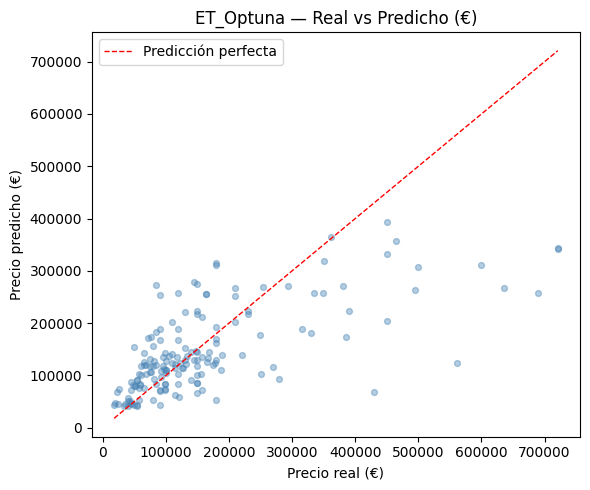

In [ ]:
y_real_eur = np.exp(y_test.values)
y_pred_eur = np.exp(y_pred_test)
error_eur  = np.abs(y_real_eur - y_pred_eur)

print(f'Error absoluto medio  : {error_eur.mean():>10,.0f} €')
print(f'Error mediano         : {np.median(error_eur):>10,.0f} €')
print(f'Error percentil 90    : {np.percentile(error_eur, 90):>10,.0f} €')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_real_eur, y_pred_eur, alpha=0.4, color='steelblue', s=18)
lim = [min(y_real_eur.min(), y_pred_eur.min()), max(y_real_eur.max(), y_pred_eur.max())]
ax.plot(lim, lim, 'r--', linewidth=1, label='Predicción perfecta')
ax.set_xlabel('Precio real (€)')
ax.set_ylabel('Precio predicho (€)')
ax.set_title(f'{mejor} — Real vs Predicho (€)')
ax.legend()
plt.tight_layout()
plt.show()